In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [10]:
df = pd.read_csv('crop_yield.csv')

In [11]:
df

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251
...,...,...,...,...,...,...,...,...,...,...
999995,West,Silt,Rice,302.805345,27.987428,False,False,Sunny,76,1.347586
999996,South,Chalky,Barley,932.991383,39.661039,True,False,Rainy,93,7.311594
999997,North,Peaty,Cotton,867.362046,24.370042,True,False,Cloudy,108,5.763182
999998,West,Silt,Wheat,492.812857,33.045505,False,False,Sunny,102,2.070159


In [12]:
df.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


In [13]:
df.shape

(1000000, 10)

In [14]:
df.tail()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
999995,West,Silt,Rice,302.805345,27.987428,False,False,Sunny,76,1.347586
999996,South,Chalky,Barley,932.991383,39.661039,True,False,Rainy,93,7.311594
999997,North,Peaty,Cotton,867.362046,24.370042,True,False,Cloudy,108,5.763182
999998,West,Silt,Wheat,492.812857,33.045505,False,False,Sunny,102,2.070159
999999,West,Sandy,Maize,180.936180,27.298847,True,False,Sunny,76,2.937243


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Region                  1000000 non-null  object 
 1   Soil_Type               1000000 non-null  object 
 2   Crop                    1000000 non-null  object 
 3   Rainfall_mm             1000000 non-null  float64
 4   Temperature_Celsius     1000000 non-null  float64
 5   Fertilizer_Used         1000000 non-null  bool   
 6   Irrigation_Used         1000000 non-null  bool   
 7   Weather_Condition       1000000 non-null  object 
 8   Days_to_Harvest         1000000 non-null  int64  
 9   Yield_tons_per_hectare  1000000 non-null  float64
dtypes: bool(2), float64(3), int64(1), object(4)
memory usage: 62.9+ MB


In [16]:
df.describe()

,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,549.981901,27.504965,104.495025,4.649472
std,259.851320,7.220608,25.953412,1.696572
min,100.000896,15.000034,60.000000,-1.147613
25%,324.891090,21.254502,82.000000,3.417637
50%,550.124061,27.507365,104.000000,4.651808
75%,774.738520,33.753267,127.000000,5.879200
max,999.998098,39.999997,149.000000,9.963372


In [17]:
df.isnull().sum()

Region                    0
Soil_Type                 0
Crop                      0
Rainfall_mm               0
Temperature_Celsius       0
Fertilizer_Used           0
Irrigation_Used           0
Weather_Condition         0
Days_to_Harvest           0
Yield_tons_per_hectare    0
dtype: int64

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df['Yield_tons_per_hectare'].describe()


count    1000000.000000
mean           4.649472
std            1.696572
min           -1.147613
25%            3.417637
50%            4.651808
75%            5.879200
max            9.963372
Name: Yield_tons_per_hectare, dtype: float64

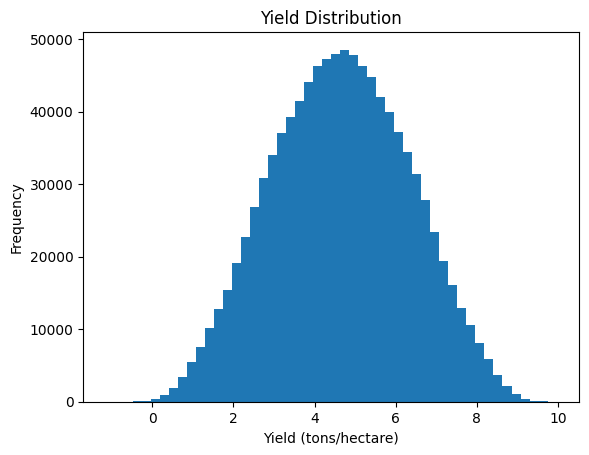

In [21]:
import matplotlib.pyplot as plt

plt.hist(df['Yield_tons_per_hectare'], bins=50)
plt.xlabel("Yield (tons/hectare)")
plt.ylabel("Frequency")
plt.title("Yield Distribution")
plt.show()

In [22]:
for col in ['Region', 'Soil_Type', 'Crop', 'Weather_Condition']:
    print(col)
    print(df[col].nunique())
    print(df[col].unique())
    print("-"*40)


Region
4
['West' 'South' 'North' 'East']
----------------------------------------
Soil_Type
6
['Sandy' 'Clay' 'Loam' 'Silt' 'Peaty' 'Chalky']
----------------------------------------
Crop
6
['Cotton' 'Rice' 'Barley' 'Soybean' 'Wheat' 'Maize']
----------------------------------------
Weather_Condition
3
['Cloudy' 'Rainy' 'Sunny']
----------------------------------------


In [23]:
df['Crop'].value_counts()

Crop
Maize      166824
Rice       166792
Barley     166777
Wheat      166673
Cotton     166585
Soybean    166349
Name: count, dtype: int64

In [24]:
df['Fertilizer_Used'].value_counts()
df['Irrigation_Used'].value_counts()


Irrigation_Used
False    500509
True     499491
Name: count, dtype: int64

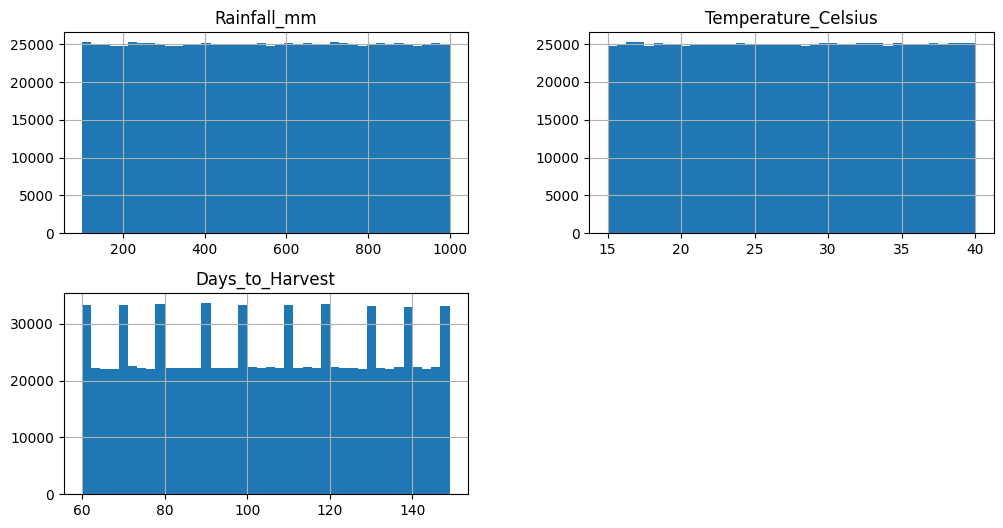

In [25]:
df[['Rainfall_mm', 'Temperature_Celsius', 'Days_to_Harvest']].hist(
    bins=40, figsize=(12,6)
)
plt.show()

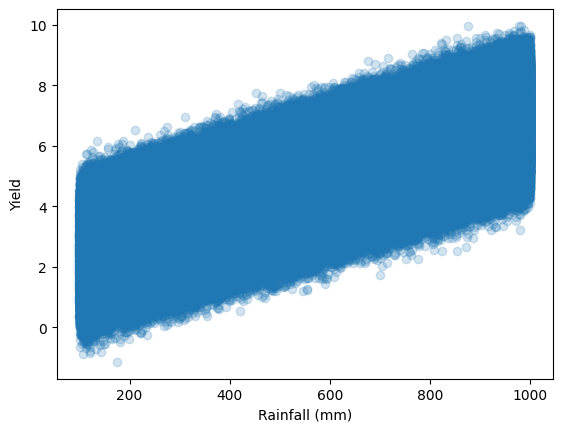

In [26]:
plt.scatter(df['Rainfall_mm'], df['Yield_tons_per_hectare'], alpha=0.2)
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield")
plt.show()


In [27]:
corr = df[['Rainfall_mm', 'Temperature_Celsius', 
           'Days_to_Harvest', 'Yield_tons_per_hectare']].corr()

corr

,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
Rainfall_mm,1.000000,-0.000123,-0.002669,0.764618
Temperature_Celsius,-0.000123,1.000000,-0.000731,0.085565
Days_to_Harvest,-0.002669,-0.000731,1.000000,-0.002591
Yield_tons_per_hectare,0.764618,0.085565,-0.002591,1.000000


In [28]:
df = df[df['Yield_tons_per_hectare'] >= 0]

In [29]:
df['Yield_tons_per_hectare'].min()
df.shape


(999769, 10)

In [30]:
X = df.drop(columns=['Yield_tons_per_hectare'])
y = df['Yield_tons_per_hectare']

In [31]:
X.shape, y.shape


((999769, 9), (999769,))

In [32]:
X = pd.get_dummies(
    X,
    columns=['Region', 'Soil_Type', 'Crop', 'Weather_Condition'],
    drop_first=True
)


In [33]:
X.shape
X.head()


,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Region_North,Region_South,Region_West,Soil_Type_Clay,Soil_Type_Loam,Soil_Type_Peaty,Soil_Type_Sandy,Soil_Type_Silt,Crop_Cotton,Crop_Maize,Crop_Rice,Crop_Soybean,Crop_Wheat,Weather_Condition_Rainy,Weather_Condition_Sunny
0,897.077239,27.676966,False,True,122,False,False,True,False,False,False,True,False,True,False,False,False,False,False,False
1,992.673282,18.026142,True,True,140,False,True,False,True,False,False,False,False,False,False,True,False,False,True,False
2,147.998025,29.794042,False,False,106,True,False,False,False,True,False,False,False,False,False,False,False,False,False,True
3,986.866331,16.644190,False,True,146,True,False,False,False,False,False,True,False,False,False,False,True,False,True,False
4,730.379174,31.620687,True,True,110,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False


In [34]:
X['Fertilizer_Used'] = X['Fertilizer_Used'].astype(int)
X['Irrigation_Used'] = X['Irrigation_Used'].astype(int)

In [35]:
X.dtypes

Rainfall_mm                float64
Temperature_Celsius        float64
Fertilizer_Used              int64
Irrigation_Used              int64
Days_to_Harvest              int64
Region_North                  bool
Region_South                  bool
Region_West                   bool
Soil_Type_Clay                bool
Soil_Type_Loam                bool
Soil_Type_Peaty               bool
Soil_Type_Sandy               bool
Soil_Type_Silt                bool
Crop_Cotton                   bool
Crop_Maize                    bool
Crop_Rice                     bool
Crop_Soybean                  bool
Crop_Wheat                    bool
Weather_Condition_Rainy       bool
Weather_Condition_Sunny       bool
dtype: object

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [41]:
X_scaled.shape


(999769, 20)

In [38]:
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

In [39]:
X.dtypes


Rainfall_mm                float64
Temperature_Celsius        float64
Fertilizer_Used              int64
Irrigation_Used              int64
Days_to_Harvest              int64
Region_North                 int64
Region_South                 int64
Region_West                  int64
Soil_Type_Clay               int64
Soil_Type_Loam               int64
Soil_Type_Peaty              int64
Soil_Type_Sandy              int64
Soil_Type_Silt               int64
Crop_Cotton                  int64
Crop_Maize                   int64
Crop_Rice                    int64
Crop_Soybean                 int64
Crop_Wheat                   int64
Weather_Condition_Rainy      int64
Weather_Condition_Sunny      int64
dtype: object

In [42]:
import numpy as np

np.isnan(X_scaled).sum()
np.isinf(X_scaled).sum()

np.int64(0)

In [43]:
final_df = X.copy()
final_df['Yield_tons_per_hectare'] = y.values

In [44]:
final_df.to_csv("crop_yield_final_cleaned.csv", index=False)

In [48]:
import joblib
joblib.dump(scaler, "standard_scaler.pkl")


['standard_scaler.pkl']